In [1]:
%pip install pandas numpy scikit-learn tensorflow ipywidgets pypdf python-docx matplotlib


[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install langchain langchain-openai



[notice] A new release of pip available: 22.2.2 -> 26.0.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import os
import re
import json
import random
import pickle
import textwrap
import numpy as np
import pandas as pd
import tensorflow as tf
import ipywidgets as widgets
import matplotlib.pyplot as plt

from io import BytesIO
from IPython.display import display, HTML, Markdown, clear_output

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score

from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping

from pypdf import PdfReader
from docx import Document


In [25]:
os.makedirs("models", exist_ok=True)
os.makedirs("artifacts", exist_ok=True)

In [26]:
dataset = [
    ("python pandas numpy data cleaning functions exception handling oop file handling", "Python"),
    ("python decorators lambda list comprehension generators iterators modules packages", "Python"),
    ("python classes objects inheritance polymorphism encapsulation abstraction", "Python"),
    ("sql joins normalization group by having subqueries stored procedures indexes", "SQL"),
    ("database design primary key foreign key normalization transactions sql queries", "SQL"),
    ("mysql inner join left join aggregate functions constraints views", "SQL"),
    ("machine learning regression classification clustering feature engineering model evaluation", "Machine Learning"),
    ("supervised learning unsupervised learning overfitting underfitting cross validation", "Machine Learning"),
    ("scikit learn random forest svm logistic regression metrics confusion matrix", "Machine Learning"),
    ("deep learning cnn lstm rnn tensorflow keras neural networks backpropagation", "Deep Learning"),
    ("convolutional neural network recurrent neural network sequence modeling embeddings", "Deep Learning"),
    ("lstm handles sequence data gates hidden state long term dependencies", "Deep Learning"),
    ("data structures arrays linked list stack queue trees graphs hashing recursion", "Data Structures"),
    ("binary tree bst graph traversal bfs dfs heap priority queue", "Data Structures"),
    ("algorithm complexity time complexity space complexity searching sorting recursion", "Data Structures"),
    ("flask django rest api backend authentication authorization crud routing", "Web Development"),
    ("html css javascript frontend backend full stack web application api", "Web Development"),
    ("http request response json session cookies database integration deployment", "Web Development"),
    ("power bi excel tableau dashboard reporting data visualization analytics", "Data Analysis"),
    ("data analysis exploratory data analysis statistics visualization insights dashboard", "Data Analysis"),
    ("excel pivot table charts reporting kpi trend analysis business analysis", "Data Analysis"),
    ("aws docker ci cd linux shell deployment cloud devops automation", "Cloud/DevOps"),
    ("cloud computing kubernetes docker containers devops pipeline monitoring", "Cloud/DevOps"),
    ("jenkins github actions aws ec2 s3 deployment automation infrastructure", "Cloud/DevOps"),
    ("communication teamwork leadership conflict resolution behavioral interview hr questions", "HR"),
    ("recruitment onboarding employee engagement interpersonal skills adaptability", "HR"),
    ("tell me about yourself strengths weaknesses teamwork leadership challenge", "HR"),
]

In [27]:
def augment_text(text, n=8):
    words = text.split()
    augmented = []
    for _ in range(n):
        shuffled = words[:]
        random.shuffle(shuffled)
        augmented.append(" ".join(shuffled))
    return augmented

rows = []
for text, topic in dataset:
    rows.append((text, topic))
    for aug in augment_text(text, n=10):
        rows.append((aug, topic))

df = pd.DataFrame(rows, columns=["text", "topic"])
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print("Total rows:", len(df))
df.head()

Total rows: 297


,text,topic
0,authentication django backend api authorizatio...,Web Development
1,data visualization statistics dashboard insigh...,Data Analysis
2,mysql views inner aggregate constraints join j...,SQL
3,algorithm complexity time complexity space com...,Data Structures
4,numpy pandas exception functions python handli...,Python


In [28]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"[^a-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["text"] = df["text"].apply(clean_text)
df.head()

,text,topic
0,authentication django backend api authorizatio...,Web Development
1,data visualization statistics dashboard insigh...,Data Analysis
2,mysql views inner aggregate constraints join j...,SQL
3,algorithm complexity time complexity space com...,Data Structures
4,numpy pandas exception functions python handli...,Python


In [29]:
texts = df["text"].tolist()
labels = df["topic"].tolist()

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(labels)

MAX_WORDS = 5000
MAX_LEN = 30

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(texts)

sequences = tokenizer.texts_to_sequences(texts)
X = pad_sequences(sequences, maxlen=MAX_LEN, padding="post", truncating="post")

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("Classes:", list(label_encoder.classes_))

Train shape: (237, 30)
Test shape: (60, 30)
Classes: [np.str_('Cloud/DevOps'), np.str_('Data Analysis'), np.str_('Data Structures'), np.str_('Deep Learning'), np.str_('HR'), np.str_('Machine Learning'), np.str_('Python'), np.str_('SQL'), np.str_('Web Development')]


In [30]:
def build_lstm_model(num_classes):
    model = Sequential([
        Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
        LSTM(64),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

lstm_model = build_lstm_model(len(label_encoder.classes_))
lstm_model.summary()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [31]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_lstm = lstm_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.1270 - loss: 2.1988 - val_accuracy: 0.0417 - val_loss: 2.2085
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1005 - loss: 2.1993 - val_accuracy: 0.0417 - val_loss: 2.2126
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1376 - loss: 2.1950 - val_accuracy: 0.1042 - val_loss: 2.2033
Epoch 4/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1534 - loss: 2.1947 - val_accuracy: 0.1042 - val_loss: 2.2048
Epoch 5/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2116 - loss: 2.1712 - val_accuracy: 0.1250 - val_loss: 2.0879
Epoch 6/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2751 - loss: 1.9597 - val_accuracy: 0.1250 - val_loss: 1.9102
Epoch 7/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2698 - loss: 1.8048 - val_accuracy: 0.1250 - val_loss: 1.7761
Epoch 8/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2222 - loss: 1.7040 - val_accuracy: 0.1250 - val_loss

In [32]:
def build_cnn_model(num_classes):
    model = Sequential([
        Embedding(MAX_WORDS, 64, input_length=MAX_LEN),
        Conv1D(128, 3, activation="relu"),
        GlobalMaxPooling1D(),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dense(num_classes, activation="softmax")
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

cnn_model = build_cnn_model(len(label_encoder.classes_))
cnn_model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_1          │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [33]:
history_cnn = cnn_model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=12,
    batch_size=16,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1005 - loss: 2.1877 - val_accuracy: 0.1458 - val_loss: 2.1561
Epoch 2/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1640 - loss: 2.1267 - val_accuracy: 0.1875 - val_loss: 2.1045
Epoch 3/12
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.2116 - loss: 2.0406 - val_accuracy: 0.1875 - val_loss: 2.0083


In [34]:
lstm_loss, lstm_acc = lstm_model.evaluate(X_test, y_test, verbose=0)
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test, verbose=0)

print("LSTM Accuracy:", round(lstm_acc, 4))
print("CNN Accuracy :", round(cnn_acc, 4))

LSTM Accuracy: 0.5667
CNN Accuracy : 0.1


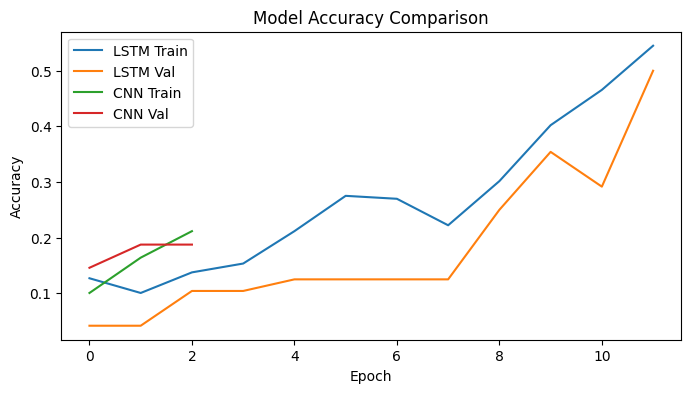

In [35]:
plt.figure(figsize=(8,4))
plt.plot(history_lstm.history["accuracy"], label="LSTM Train")
plt.plot(history_lstm.history["val_accuracy"], label="LSTM Val")
plt.plot(history_cnn.history["accuracy"], label="CNN Train")
plt.plot(history_cnn.history["val_accuracy"], label="CNN Val")
plt.title("Model Accuracy Comparison")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [36]:
best_model_name = "lstm_model.keras" if lstm_acc >= cnn_acc else "cnn_model.keras"

if best_model_name == "lstm_model.keras":
    lstm_model.save("models/best_model.keras")
else:
    cnn_model.save("models/best_model.keras")

with open("artifacts/tokenizer.pkl", "wb") as f:
    pickle.dump(tokenizer, f)

with open("artifacts/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

print("Saved best model:", best_model_name)

Saved best model: lstm_model.keras


In [37]:
def extract_text_from_pdf_bytes(file_bytes):
    text = ""
    reader = PdfReader(BytesIO(file_bytes))
    for page in reader.pages:
        page_text = page.extract_text()
        if page_text:
            text += page_text + "\n"
    return text.strip()

def extract_text_from_docx_bytes(file_bytes):
    doc = Document(BytesIO(file_bytes))
    return "\n".join([p.text for p in doc.paragraphs]).strip()

def extract_text_from_txt_bytes(file_bytes):
    return file_bytes.decode("utf-8", errors="ignore").strip()

def parse_uploaded_file(file_name, file_bytes):
    lower = file_name.lower()
    if lower.endswith(".pdf"):
        return extract_text_from_pdf_bytes(file_bytes)
    elif lower.endswith(".docx"):
        return extract_text_from_docx_bytes(file_bytes)
    elif lower.endswith(".txt"):
        return extract_text_from_txt_bytes(file_bytes)
    else:
        raise ValueError("Please upload PDF, DOCX, or TXT file only.")

In [38]:
best_model = load_model("models/best_model.keras")

with open("artifacts/tokenizer.pkl", "rb") as f:
    tokenizer = pickle.load(f)

with open("artifacts/label_encoder.pkl", "rb") as f:
    label_encoder = pickle.load(f)

def preprocess_input_text(text):
    text = clean_text(text)
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    return padded

def predict_topic_probabilities(text):
    x = preprocess_input_text(text)
    probs = best_model.predict(x, verbose=0)[0]
    
    results = []
    for i, p in enumerate(probs):
        results.append((label_encoder.classes_[i], float(p)))
    
    results = sorted(results, key=lambda x: x[1], reverse=True)
    return results

def get_top_topics(text, top_k=3):
    probs = predict_topic_probabilities(text)
    return probs[:top_k]

In [39]:
QUESTION_BANK = {

"Python":[
"What is Python and why is it popular?",
"What is the difference between list and tuple?",
"What are Python decorators?",
"What is a lambda function?",
"What is list comprehension?",
"What is the difference between deep copy and shallow copy?",
"What are generators in Python?",
"What are iterators?",
"What is exception handling in Python?",
"What is the use of __init__ method?",
"What are Python modules and packages?",
"What is the difference between == and is operator?",
"What is multithreading in Python?",
"What are Python dictionaries?",
"What is garbage collection in Python?"
],

"SQL":[
"What is SQL?",
"What is the difference between WHERE and HAVING?",
"Explain INNER JOIN and LEFT JOIN.",
"What is normalization?",
"What is denormalization?",
"What are indexes in SQL?",
"What is a primary key?",
"What is a foreign key?",
"What is a stored procedure?",
"What is a view in SQL?",
"What is the difference between DELETE and TRUNCATE?",
"What is GROUP BY clause?",
"What are aggregate functions?",
"What is a subquery?",
"What is ACID property?"
],

"Machine Learning":[
"What is Machine Learning?",
"What is supervised learning?",
"What is unsupervised learning?",
"What is overfitting?",
"What is underfitting?",
"What is cross validation?",
"What is feature engineering?",
"What is classification?",
"What is regression?",
"What is a confusion matrix?",
"What is precision and recall?",
"What is F1 score?",
"What is bias-variance tradeoff?",
"What is model evaluation?",
"What is hyperparameter tuning?"
],

"Deep Learning":[
"What is Deep Learning?",
"What is a neural network?",
"What is the difference between CNN and LSTM?",
"What is backpropagation?",
"What is an activation function?",
"What is ReLU?",
"What is dropout in neural networks?",
"What is gradient descent?",
"What is a convolutional layer?",
"What is pooling in CNN?",
"What is sequence modeling?",
"What are hidden layers?",
"What is vanishing gradient problem?",
"What is batch normalization?",
"What is transfer learning?"
],

"Data Structures":[
"What is a data structure?",
"What is the difference between stack and queue?",
"What is recursion?",
"What is a linked list?",
"What is a binary tree?",
"What is a binary search tree?",
"What is graph traversal?",
"What is BFS?",
"What is DFS?",
"What is time complexity?",
"What is space complexity?",
"What is hashing?",
"What is a heap?",
"What is a priority queue?",
"What is dynamic programming?"
],

"Web Development":[
"What is web development?",
"What is HTML?",
"What is CSS?",
"What is JavaScript?",
"What is REST API?",
"What is the difference between GET and POST?",
"What is session management?",
"What is authentication?",
"What is authorization?",
"What is a web server?",
"What is frontend vs backend?",
"What is JSON?",
"What is AJAX?",
"What is MVC architecture?",
"What is responsive design?"
],

"Data Analysis":[
"What is data analysis?",
"What is exploratory data analysis?",
"What is data cleaning?",
"What is the difference between mean and median?",
"What is standard deviation?",
"What is correlation?",
"What is data visualization?",
"What are dashboards?",
"What is Power BI?",
"What is Tableau?",
"What is KPI?",
"What is trend analysis?",
"What is outlier detection?",
"What is hypothesis testing?",
"What is statistical significance?"
],

"Cloud/DevOps":[
"What is cloud computing?",
"What is AWS?",
"What is Docker?",
"What is Kubernetes?",
"What is CI/CD?",
"What is DevOps?",
"What is infrastructure as code?",
"What is containerization?",
"What is serverless computing?",
"What is load balancing?",
"What is monitoring in DevOps?",
"What is continuous integration?",
"What is continuous deployment?",
"What is a microservice architecture?",
"What is autoscaling?"
],

"HR":[
"Tell me about yourself.",
"What are your strengths?",
"What are your weaknesses?",
"Why do you want this job?",
"Where do you see yourself in five years?",
"Describe a challenging situation you faced.",
"How do you handle pressure?",
"Why should we hire you?",
"Describe a time you worked in a team.",
"What motivates you?",
"What are your career goals?",
"What is your biggest achievement?",
"What do you know about our company?",
"How do you handle criticism?",
"What is your leadership style?"
]

}

In [40]:
import random

def generate_questions_local(topics):

    output = []

    output.append("## Detected Topics\n")

    for topic, score in topics:
        output.append(f"- **{topic}** ({score:.2%})")

    output.append("\n---\n")

    for topic, score in topics:

        output.append(f"## {topic} Questions\n")

        questions = QUESTION_BANK.get(topic, [])

        if questions:
            selected = random.sample(questions, min(5, len(questions)))

            for i, q in enumerate(selected, 1):
                output.append(f"{i}. {q}")

        else:
            output.append("No questions available.")

        output.append("")

    return "\n".join(output)

In [41]:
import ipywidgets as widgets
from IPython.display import display, HTML, Markdown, clear_output

In [42]:
title = widgets.HTML("""
<div style='background: linear-gradient(90deg, #4f46e5, #7c3aed); 
            padding: 16px; border-radius: 14px; color: white;'>
    <h2 style='margin: 0;'>Interview Question Generator</h2>
    <p style='margin: 6px 0 0 0;'>Upload a resume or job description and generate topic-wise interview questions</p>
</div>
""")

upload_widget = widgets.FileUpload(
    accept=".pdf,.docx,.txt",
    multiple=False
)

text_area = widgets.Textarea(
    placeholder="Or paste resume/job description text here...",
    layout=widgets.Layout(width="100%", height="180px")
)

top_k_slider = widgets.IntSlider(
    value=3,
    min=1,
    max=5,
    step=1,
    description="Top Topics:",
    layout=widgets.Layout(width="350px")
)

question_mode = widgets.Dropdown(
    options=["Local Question Bank"],
    value="Local Question Bank",
    description="Generator:",
    layout=widgets.Layout(width="320px")
)

generate_button = widgets.Button(
    description="Generate Questions",
    button_style="success",
    icon="check",
    layout=widgets.Layout(width="220px", height="42px")
)

clear_button = widgets.Button(
    description="Clear",
    button_style="warning",
    icon="trash",
    layout=widgets.Layout(width="120px", height="42px")
)

status_html = widgets.HTML("<b>Status:</b> Ready")

output_area = widgets.Output(
    layout={
        "border": "1px solid #d1d5db",
        "padding": "12px",
        "max_height": "500px",
        "overflow_y": "auto"
    }
)

controls = widgets.HBox([top_k_slider, question_mode])
buttons = widgets.HBox([generate_button, clear_button])

ui = widgets.VBox([
    title,
    widgets.HTML("<h4>Upload Resume / Job Description</h4>"),
    upload_widget,
    widgets.HTML("<h4>Or Paste Text</h4>"),
    text_area,
    controls,
    buttons,
    status_html,
    output_area
])

display(ui)

In [43]:
def get_uploaded_file():
    if not upload_widget.value:
        return None, None
    
    uploaded_file = list(upload_widget.value.values())[0]
    file_name = uploaded_file["metadata"]["name"]
    file_bytes = uploaded_file["content"]
    return file_name, file_bytes

def topics_as_html(topics):
    chips = ""
    for topic, score in topics:
        chips += f"""
        <span style='display:inline-block; background:#e0e7ff; color:#312e81;
                     padding:6px 12px; margin:4px; border-radius:16px; font-weight:600;'>
            {topic} ({score:.1%})
        </span>
        """
    return chips

def on_generate_clicked(b):
    with output_area:
        clear_output()
    
    try:
        status_html.value = "<b>Status:</b> Reading input..."
        
        text = text_area.value.strip()
        
        if not text:
            file_name, file_bytes = get_uploaded_file()
            if file_name and file_bytes:
                text = parse_uploaded_file(file_name, file_bytes)
            else:
                status_html.value = "<b>Status:</b> Please upload a file or paste text."
                return
        
        if len(text.strip()) < 20:
            status_html.value = "<b>Status:</b> Input text is too short."
            return
        
        status_html.value = "<b>Status:</b> Predicting topics..."
        top_topics = get_top_topics(text, top_k=top_k_slider.value)
        
        status_html.value = "<b>Status:</b> Generating questions..."
        questions_md = generate_questions_local(top_topics)
        
        with output_area:
            clear_output()
            display(HTML("<h3>Predicted Topics</h3>"))
            display(HTML(topics_as_html(top_topics)))
            display(Markdown("---"))
            display(Markdown(questions_md))
        
        status_html.value = "<b>Status:</b> Done"
    
    except Exception as e:
        status_html.value = f"<b>Status:</b> Error: {str(e)}"
        with output_area:
            clear_output()
            print("Error:", e)

def on_clear_clicked(b):
    text_area.value = ""
    try:
        upload_widget.value.clear()
        upload_widget._counter = 0
    except:
        pass
    status_html.value = "<b>Status:</b> Ready"
    with output_area:
        clear_output()

generate_button.on_click(on_generate_clicked)
clear_button.on_click(on_clear_clicked)

In [44]:
# ------- Topic Prediction Functions -------

def preprocess_input_text(text):
    text = text.lower()
    seq = tokenizer.texts_to_sequences([text])
    padded = pad_sequences(seq, maxlen=MAX_LEN, padding="post", truncating="post")
    return padded


def predict_topic_probabilities(text):
    x = preprocess_input_text(text)

    probs = best_model.predict(x, verbose=0)[0]

    results = []
    for i, p in enumerate(probs):
        results.append((label_encoder.classes_[i], float(p)))

    results = sorted(results, key=lambda x: x[1], reverse=True)
    return results


def get_top_topics(text, top_k=3):
    probs = predict_topic_probabilities(text)
    return probs[:top_k]

In [45]:
sample_text = """
I have experience in Python, pandas, NumPy, machine learning,
SQL queries, data analysis, dashboard creation, and teamwork.
"""

top_topics = get_top_topics(sample_text, top_k=3)

print(top_topics)
print(generate_questions_local(top_topics))

[(np.str_('Python'), 0.2745503783226013), (np.str_('Machine Learning'), 0.21446101367473602), (np.str_('Data Analysis'), 0.1830209195613861)]
## Detected Topics

- **Python** (27.46%)
- **Machine Learning** (21.45%)
- **Data Analysis** (18.30%)

---

## Python Questions

1. What is the use of __init__ method?
2. What is the difference between deep copy and shallow copy?
3. What are Python dictionaries?
4. What is the difference between == and is operator?
5. What are iterators?

## Machine Learning Questions

1. What is classification?
2. What is model evaluation?
3. What is cross validation?
4. What is regression?
5. What is supervised learning?

## Data Analysis Questions

1. What is standard deviation?
2. What is statistical significance?
3. What is KPI?
4. What are dashboards?
5. What is outlier detection?

